# Correlation

(https://campus.datacamp.com/courses/introduction-to-statistics-in-python/correlation-and-experimental-design-4)

## Required imports

In [1]:
from pathlib import Path
from IPython.display import Image, display

import base64
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data sources

### Get DataFrame

In [2]:
def get_df(file_name: str):
  filepath = Path("..")/"data"/file_name
  return pd.read_csv(filepath, index_col=0)

### Get mermaid diagram

In [3]:
def display_mermaid(graph_code):
    """Converts your diagram string into a base64 string."""
    """Then, retrieves a rendered PNG image from the `mermaid.ink` web service"""
    graphbytes = graph_code.encode("ascii")
    base64_bytes = base64.b64encode(graphbytes)
    base64_string = base64_bytes.decode("ascii")
    url = f"https://mermaid.ink/img/{base64_string}"
    display(Image(url=url))

### Sources

In [4]:
world_happiness = get_df('world_happiness.csv')

### `seaborn.scatterplot`

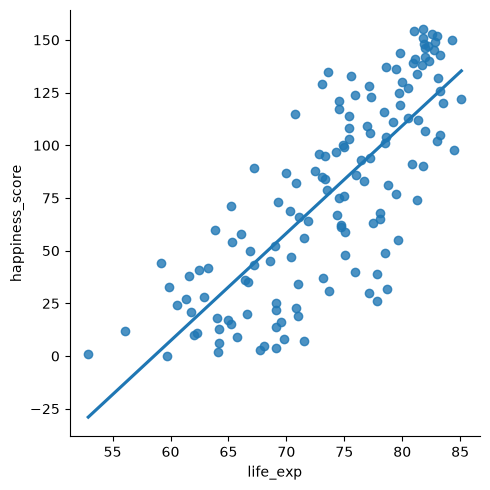

In [5]:
# Create scatterplot of happiness_score vs life_exp with trendline
sns.lmplot(data=world_happiness, x='life_exp', y='happiness_score', ci=None)

# Show plot
plt.show()

### `pandas.DataFrame.corr`

In [6]:
cor = world_happiness['life_exp'].corr(world_happiness['happiness_score'])
cor

np.float64(0.7802249053272065)

## Non-linear relationships

This is because the relationship between the two variables is a quadratic relationship, not a linear relationship.

The correlation coefficient measures the strength of linear relationships, and linear relationships only.

Just like any summary statistic, correlation shouldn't be used blindly, and you should always visualize your data when possible

## Transformations

## Log transformation

When data is highly skewed like this, we can apply a log transformation. We'll create a new column called log_bodywt which holds the log of each body weight. We can do this using np-dot-log.

If we plot the log of bodyweight versus awake time, the relationship looks much more linear than the one between regular bodyweight and awake time. The correlation between the log of bodyweight and awake time is about 0-point-57, which is much higher than the 0-point-3 we had before.

### Other transformations

In addition to the log transformation, there are lots of other transformations that can be used to make a relationship more linear.

The choice of transformation will depend on the data and how skewed it is. These can be applied in different combinations to x and y, for example, you could apply a log transformation to both x and y, or a square root transformation to x and a reciprocal transformation to y

### Why use transformation

- Certain statistical methods rely on variables having a linear relationship
  - Correlation coefficient
  - Linear regression (requires variables to be related in a linear manner)

## Correlation does not equal causation

Correlation does not imply causation. This means that if x and y are correlated, x doesn't necessarily cause y.

## Confounding

### Example

#### Coffee vs Lung cancer

A phenomenon called confounding can lead to spurious correlations. Let's say we want to know if drinking coffee causes lung cancer. Looking at the data, we find that coffee drinking and lung cancer are correlated, which may lead us to think that drinking more coffee will give you lung cancer

In [7]:
graph="""
graph TD
    S["Smoking<br>(confounder)"]
    C["Coffee drinking<br>(x)"]
    L["Lung cancer<br>(y)"]

    S <-->|association| C
    S -->|causation| L
    C <-->|association| L
"""
display_mermaid(graph)


It turns out that coffee does not cause lung cancer and is only associated with it, but it appeared causal due to the third variable, smoking. This third variable is called a confounder, or lurking variable. This means that the relationship of interest between coffee and lung cancer is a spurious correlation.

#### Holidays and Retail sales

In [8]:
holiday_retails_diagram = """
graph TD
    SD["Special deals<br>(confounder)"]
    H["Holidays<br>(x)"]
    RS["Retail sales<br>(y)"]

    SD <--> H
    SD --> RS
    H --> RS
"""
display_mermaid(holiday_retails_diagram)

Another example of this is the relationship between holidays and retail sales. While it might be that people buy more around holidays as a way of celebrating, it's hard to tell how much of the increased sales is due to holidays, and how much is due to the special deals and promotions that often run around holidays. Here, special deals confound the relationship between holidays and sales.

### What can't correlation measure?

While the correlation coefficient is a convenient way to quantify the strength of a relationship between two variables, it's far from perfect.

In this exercise, you'll explore one of the caveats of the correlation coefficient by examining the relationship between a country's GDP per capita (gdp_per_cap) and happiness score.

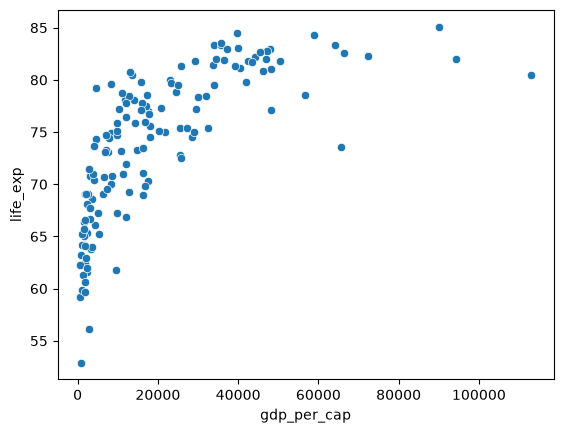

In [9]:
# Scatterplot of gdp_per_cap and life_exp
sns.scatterplot(x='gdp_per_cap', y='life_exp', data=world_happiness)

# Show plot
plt.show()

In [10]:
corr = world_happiness['gdp_per_cap'].corr(world_happiness['life_exp'])
corr

np.float64(0.7019547642148015)

#### Question - use of correlation
The correlation between GDP per capita and life expectancy is 0.7.

Why is correlation not the best way to measure the relationship between these two variables?

#### Answer - use of correlation

Correlation only measures linear relationships.